In [1]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Set a nice visual theme
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (12, 6)

# Define your directory
RESULTS_DIR = "../results_v2/new"


my husband have a brain cancer . we think that.   he had a constipation, weakness in his hand, foot weakness. is that serious problem doctor ?  what is that brain tumor stage ? actually we want to know is it brain cancer ? that s the way we admit him to hospital. (he had a constipation, weakness in his hand, foot weakness).

I m a 32 yr old healthy female, 5 6 150lbs who runs 3-4 miles, 3-4 times weekly. no smoking, drugs or alcohol use. not on any medications. Last Monday I was suddenly admitted to the hospital for headache pain in left temple and behind left eye with bp of 132/78 (normal bp 118/74). I Had catscan, mri, echocardiogram , carotid ultrasound, in 3 day stay. diagnosis of bell s palsy put on antiviral as well as trigeminal neuralgia.  It seems as if nerve compression somewhere (4 &amp; 5 vertabrae degenerative disc disease managed with an occasional Aleve) is causing more pain. Is this possible? Should I be on meds?



In [2]:
import orjson
from pathlib import Path
from typing import Annotated, Any, Literal

import typer

from dataloader import ArchEHRDataLoader

from providers.base import BaseProvider, Messages
from providers.local import LocalProvider
from providers.cloud import CloudProvider


xml_file = "../../data/dev/archehr-qa.xml"

# --- 2. Load XML Cases ---
print(f"Loading XML cases from {xml_file}...")
xml_cases = ArchEHRDataLoader(xml_file).load()
print(f"Loaded {len(xml_cases)} cases from XML.")


ModuleNotFoundError: No module named 'dataloader'

In [3]:
xml_cases[0]

NameError: name 'xml_cases' is not defined

In [4]:

# --- 3. Load Prompt Template ---
print(f"Loading prompt template from {prompt_file}...")
with open(prompt_file, "r") as f:
    prompt_dict = orjson.loads(f.read())
prompt_template = prompt_dict[str(prompt_index)]

# list[(case, prompt)]
p: list[tuple[dict[str, Any], Messages]] = [
    (case, provider.build_prompt(prompt_template, case)) for case in xml_cases
]
print(f"Built {len(p)} prompts.")

NameError: name 'prompt_file' is not defined

In [3]:
def load_metrics(directory):
    data = []
    path = Path(directory)
    
    # Iterate over all json files
    for file_path in path.glob("*.json"):
        try:
            with open(file_path, 'r') as f:
                metrics = json.load(f)
            
            # Parse filename: "model-name_prompt_1.json"
            filename = file_path.stem # removes .json
            
            # reliable split based on the standard naming convention
            if "_prompt_" in filename:
                model_name, prompt_part = filename.split("_prompt_")
                prompt_id = prompt_part
            else:
                # Fallback if naming convention breaks
                model_name = filename
                prompt_id = "unknown"

            # Add metadata to the metrics dictionary
            metrics['model'] = model_name
            metrics['prompt_id'] = prompt_id
            metrics['filename'] = filename
            
            data.append(metrics)
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

    # Create DataFrame
    df = pd.DataFrame(data)
    
    # Convert prompt_id to numeric if possible for better sorting, else keep string
    try:
        df['prompt_id'] = pd.to_numeric(df['prompt_id'])
    except:
        pass
        
    return df

# Load the data
df = load_metrics(RESULTS_DIR)

# Sort by Overall Score (descending)
df = df.sort_values(by="overall_score", ascending=False).reset_index(drop=True)

# Display the top 5 rows
print(f"Loaded {len(df)} result files.")
display(df.head())

Loaded 70 result files.


,rouge1,rouge2,rougeL,rougeLsum,bertscore,medcon,alignscore,overall_score,model,prompt_id,filename
0,20.151808,4.940886,18.166258,18.166258,29.981147,20.750000,17.274461,21.542967,Echelon-AI-Med-Qwen2-7B,3,Echelon-AI-Med-Qwen2-7B_prompt_3
1,19.897333,3.211901,17.178566,17.178566,33.615966,25.526190,8.788562,21.277321,anthropic-claude-sonnet-4-5,3,anthropic-claude-sonnet-4-5_prompt_3
2,22.391828,5.559412,19.588970,19.588970,32.889053,23.859524,8.505639,21.210796,anthropic-claude-sonnet-4-5,10,anthropic-claude-sonnet-4-5_prompt_10
3,20.918918,3.550847,18.211057,18.211057,29.097697,17.404762,17.372027,20.521386,Echelon-AI-Med-Qwen2-7B,7,Echelon-AI-Med-Qwen2-7B_prompt_7
4,21.984610,3.463833,19.632836,19.632836,30.027597,18.166667,13.474480,20.325395,Echelon-AI-Med-Qwen2-7B,1,Echelon-AI-Med-Qwen2-7B_prompt_1


In [4]:
# 1. Define a helper to categorize models
def get_model_category(name):
    name = name.lower()
    
    # --- Proprietary ---
    # Look for key API model names (excluding open weights versions)
    if any(x in name for x in ['gpt-5', 'gpt-4', 'claude', 'gemini-3', 'qwen3-max', 'midjourney', 'grok']):
        # Exception: if it explicitly says "oss" (open source software)
        if 'oss' in name: 
            return "Large OSS"
        return "Proprietary"
        
    # --- Large Open Source (120B+) ---
    # Look for explicit size indicators or known large models like DeepSeek V3
    if any(x in name for x in ['120b', '405b', 'deepseek', '235b', "llama-4", "glm", "kimi"]):
        return "Large OSS"
        
    # --- Local Open Source ---
    # Everything else (usually 7B, 8B, 14B, 32B, 70B, etc.)
    return "Local OSS"

# 2. Calculate Model Averages first (for sorting purposes)
model_stats = df.groupby('model')['overall_score'].mean().reset_index()
model_stats.rename(columns={'overall_score': 'avg_score'}, inplace=True)

# 3. Apply Category
model_stats['category'] = model_stats['model'].apply(get_model_category)

# 4. Define Sort Order: Proprietary -> Large OSS -> Local OSS
# We map these to 0, 1, 2 for easy sorting
cat_map = {"Proprietary": 0, "Large OSS": 1, "Local OSS": 2}
model_stats['cat_rank'] = model_stats['category'].map(cat_map)

# 5. Sort: First by Category (asc), then by Score (desc)
model_stats = model_stats.sort_values(by=['cat_rank', 'avg_score'], ascending=[True, False])

# Extract the sorted list of model names
sorted_model_names = model_stats['model'].tolist()
sorted_categories = model_stats['category'].tolist()

# Identify where the groups change (for drawing lines later)
# We store the index *after* which a new group starts
group_separators = []
for i in range(len(sorted_categories) - 1):
    if sorted_categories[i] != sorted_categories[i+1]:
        group_separators.append(i + 1)

print("Categorization Complete.")

Categorization Complete.


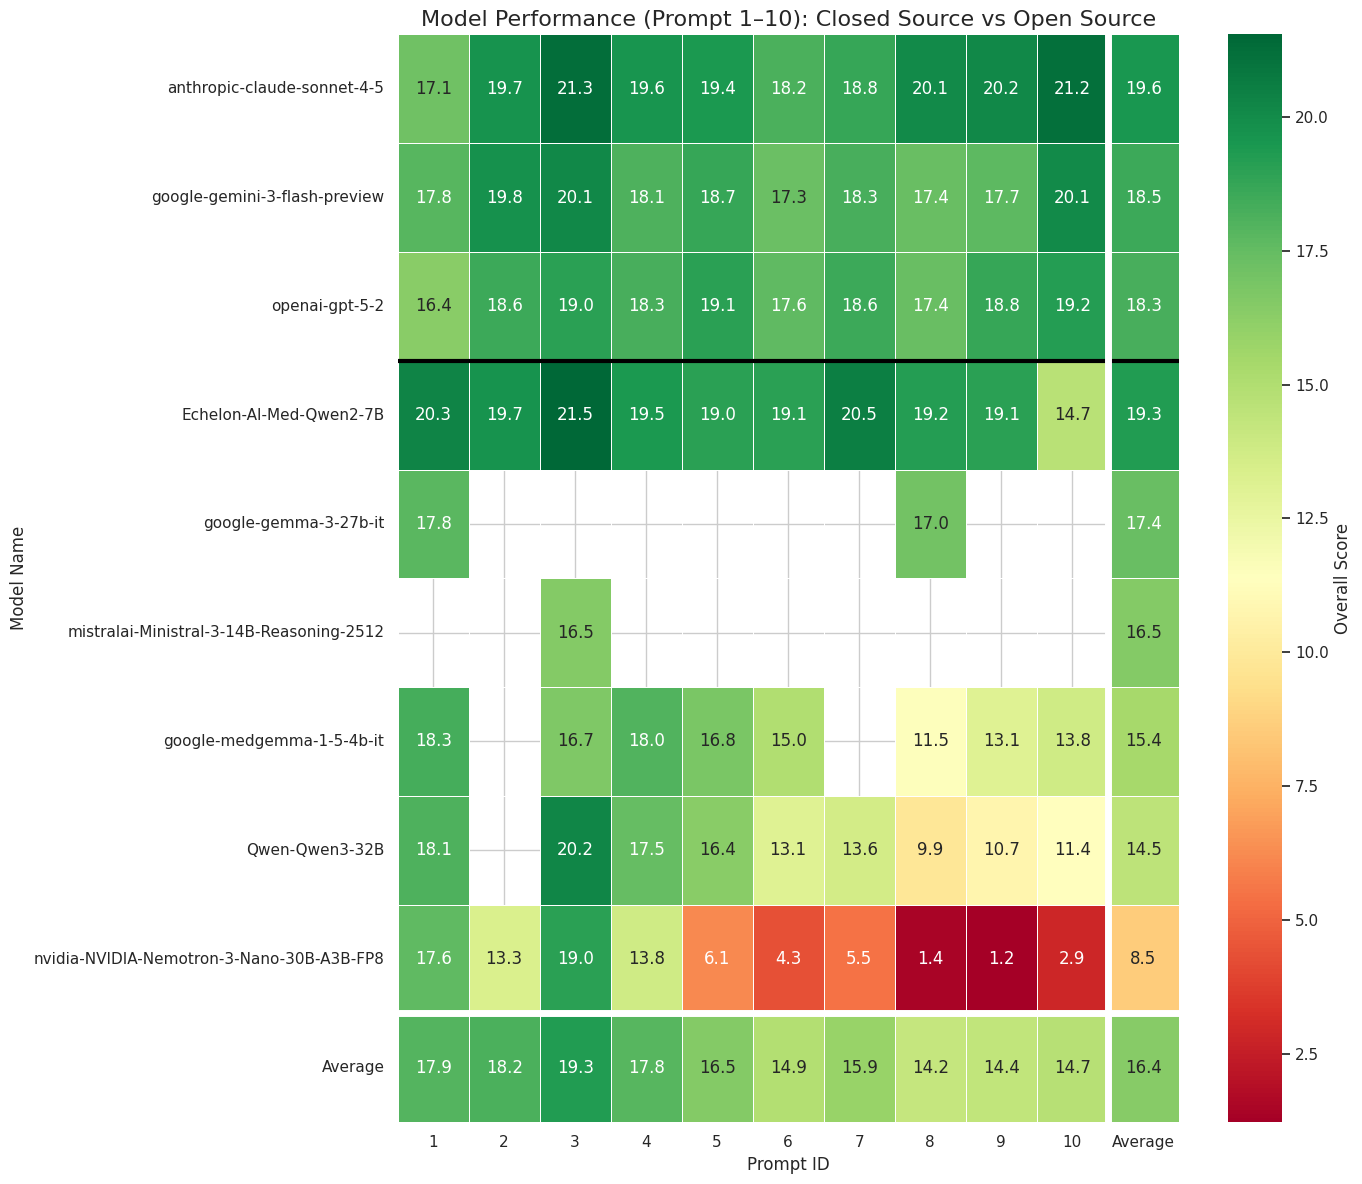

In [5]:
# 1. Create Pivot and Reindex to match our sorted order
pivot_df = df.pivot_table(index="model", columns="prompt_id", values="overall_score")
pivot_df = pivot_df.reindex(sorted_model_names)

# 2. Add 'Average' Column & Row
pivot_df['Average'] = pivot_df.mean(axis=1)
pivot_df.loc['Average'] = pivot_df.mean(axis=0)

# 3. Plot
plt.figure(figsize=(14, 12)) # Taller figure for many models
ax = sns.heatmap(
    pivot_df, 
    annot=True, 
    fmt=".1f", # Using .1f for cleaner look as per your image, use .2f for precision
    cmap="RdYlGn", 
    linewidths=0.5,
    cbar_kws={'label': 'Overall Score'}
)

# --- DRAW SEPARATORS ---
# Get plot axes
ax = plt.gca()
width = len(pivot_df.columns)
height = len(pivot_df.index)

# A. Group Separators (Horizontal lines between Proprietary/Large/Local)
for y_pos in group_separators:
    # y_pos corresponds exactly to the row index where the group splits
    ax.axhline(y=y_pos, color='black', linewidth=3, linestyle='-')
    
# B. Average Row Separator (The line before the last row)
ax.axhline(y=height - 1, color='white', linewidth=5, linestyle='-')

# C. Average Column Separator (The line before the last column)
ax.axvline(x=width - 1, color='white', linewidth=5, linestyle='-')

# D. Add Text Labels for Groups (Optional but helpful)
# We place text on the Y-axis or just rely on the visual separation
# Here is a simple way to annotate the groups on the left:
# (Coordinates are data coordinates: x=0 is left, y=row_index)
# You might need to adjust x-position (-1 or less) depending on label length

plt.title("Model Performance (Prompt 1–10): Closed Source vs Open Source", fontsize=16)
plt.ylabel("Model Name")
plt.xlabel("Prompt ID")
plt.tight_layout()
plt.show()

Loaded 332 dev result files.
Closed source: 14 models
Open source:   16 models


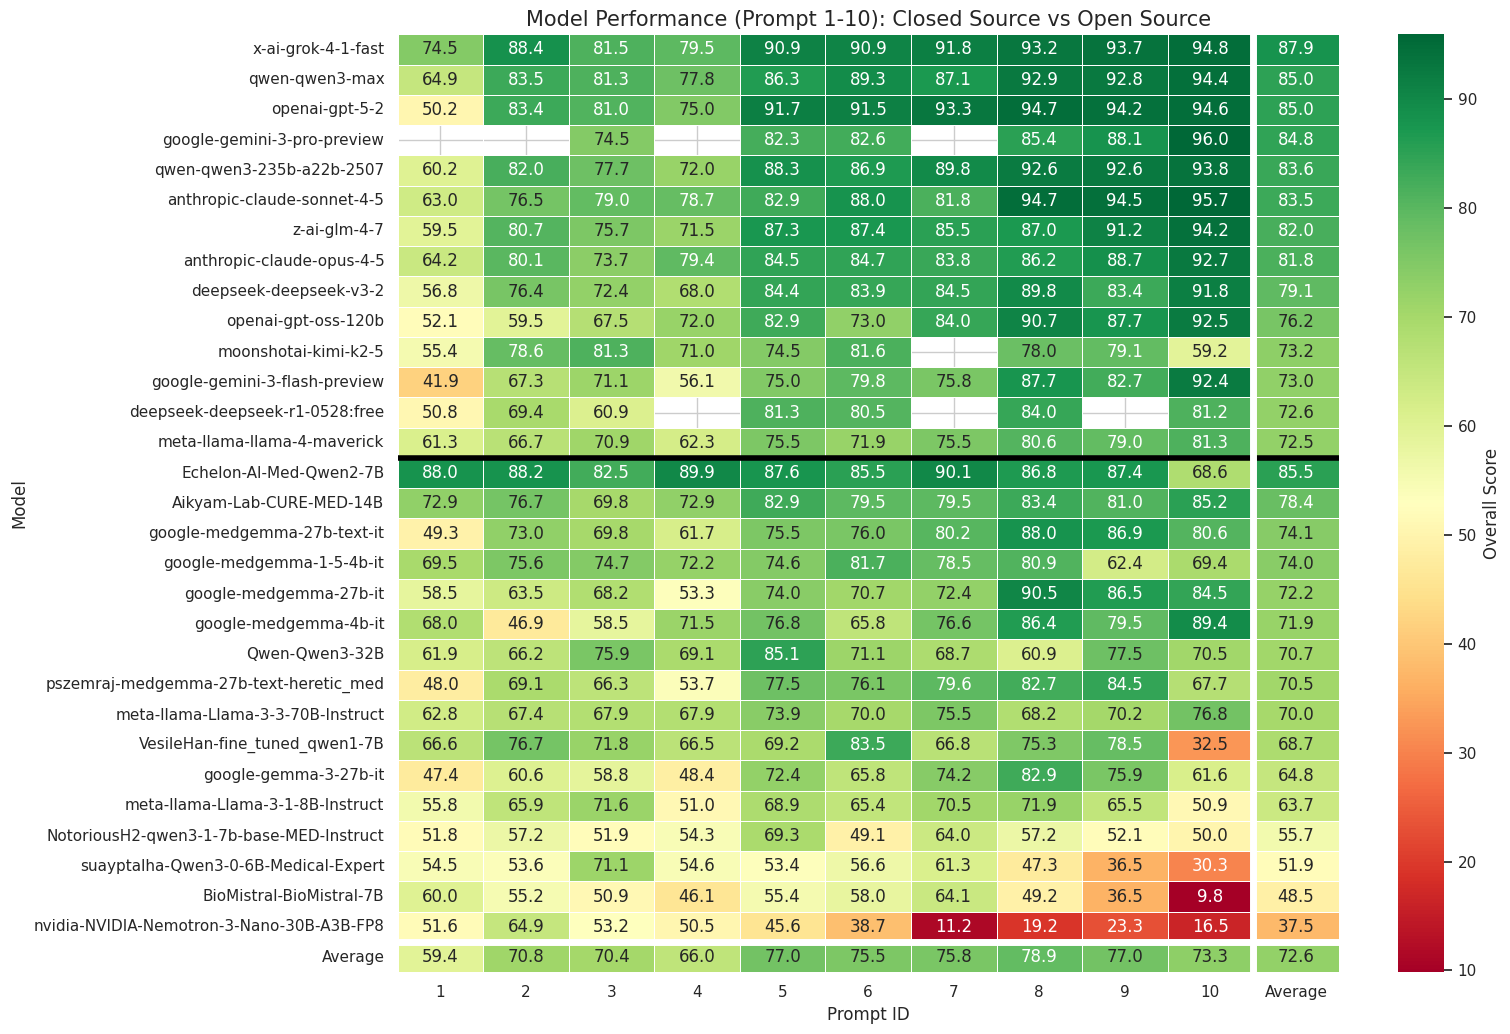

In [6]:

# ── Dev set heatmap (Closed Source vs Open Source) ───────────────────────────
DEV_RESULTS_DIR = "../results/dev"

df_dev = load_metrics(DEV_RESULTS_DIR)
df_dev['prompt_id'] = pd.to_numeric(df_dev['prompt_id'], errors='coerce')
df_dev = df_dev.dropna(subset=['prompt_id'])
df_dev['prompt_id'] = df_dev['prompt_id'].astype(int)
print(f"Loaded {len(df_dev)} dev result files.")

# ── Edit these lists to add / remove models ───────────────────────────────────
closed_source_models = [
    'x-ai-grok-4-1-fast',
    'qwen-qwen3-max',
    'openai-gpt-5-2',
    'google-gemini-3-pro-preview',
    'anthropic-claude-sonnet-4-5',
    'anthropic-claude-opus-4-5',
    'google-gemini-3-flash-preview',

    'qwen-qwen3-235b-a22b-2507',
    'z-ai-glm-4-7',
    'deepseek-deepseek-v3-2',
    'openai-gpt-oss-120b',
    'moonshotai-kimi-k2-5',
    'deepseek-deepseek-r1-0528:free',
    'meta-llama-llama-4-maverick',
]

open_source_models = [
    'Echelon-AI-Med-Qwen2-7B',
    'Aikyam-Lab-CURE-MED-14B',
    'google-medgemma-27b-text-it',
    'google-medgemma-1-5-4b-it',
    'google-medgemma-27b-it',
    'lingshu-medical-mlim-Lingshu-7B',
    'google-medgemma-4b-it',
    'lingshu-medical-mlim-Lingshu-32B',
    'Qwen-Qwen3-32B',
    'pszemraj-medgemma-27b-text-heretic_med',
    'meta-llama-Llama-3-3-70B-Instruct',
    'VesileHan-fine_tuned_qwen1-7B',
    'google-gemma-3-27b-it',
    'meta-llama-Llama-3-1-8B-Instruct',
    'NotoriousH2-qwen3-1-7b-base-MED-Instruct',
    'suayptalha-Qwen3-0-6B-Medical-Expert',
    'BioMistral-BioMistral-7B',
    'intelligent-internet-il-Medical-8B-1706',
    'nvidia-NVIDIA-Nemotron-3-Nano-30B-A3B-FP8',
    'mistrala-Ministral-3-14B-Reasoning-2512',
]
# ─────────────────────────────────────────────────────────────────────────────

all_models = closed_source_models + open_source_models

# Build pivot (keep only models present in both the list and the data)
df_dev_filtered = df_dev[df_dev['model'].isin(all_models)]
pivot_dev = df_dev_filtered.pivot_table(index='model', columns='prompt_id', values='overall_score')

pivot_dev['Average'] = pivot_dev.mean(axis=1)
pivot_dev.loc['Average'] = pivot_dev.mean(axis=0)

def get_avg_dev(model):
    try:
        return pivot_dev.loc[model, 'Average']
    except KeyError:
        return -float('inf')

closed_sorted_dev = sorted([m for m in closed_source_models if m in pivot_dev.index], key=get_avg_dev, reverse=True)
open_sorted_dev   = sorted([m for m in open_source_models   if m in pivot_dev.index], key=get_avg_dev, reverse=True)

pivot_dev = pivot_dev.reindex(closed_sorted_dev + open_sorted_dev + ['Average'])

print(f"Closed source: {len(closed_sorted_dev)} models")
print(f"Open source:   {len(open_sorted_dev)} models")

# Plot
n_closed_dev = len(closed_sorted_dev)
plt.figure(figsize=(16, max(9, (len(closed_sorted_dev) + len(open_sorted_dev)) * 0.35)))
ax = sns.heatmap(
    pivot_dev,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Overall Score'},
)

ax.axhline(y=n_closed_dev, color='black', linewidth=4)
ax.axvline(x=pivot_dev.shape[1] - 1, color='white', linewidth=5)
ax.axhline(y=pivot_dev.shape[0] - 1, color='white', linewidth=5)

plt.title('Model Performance (Prompt 1-10): Closed Source vs Open Source', fontsize=15)
plt.ylabel('Model')
plt.xlabel('Prompt ID')
plt.tight_layout()
plt.savefig('subtask1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


Loaded 332 dev result files.
Closed source: 5 models
Open source:   5 models


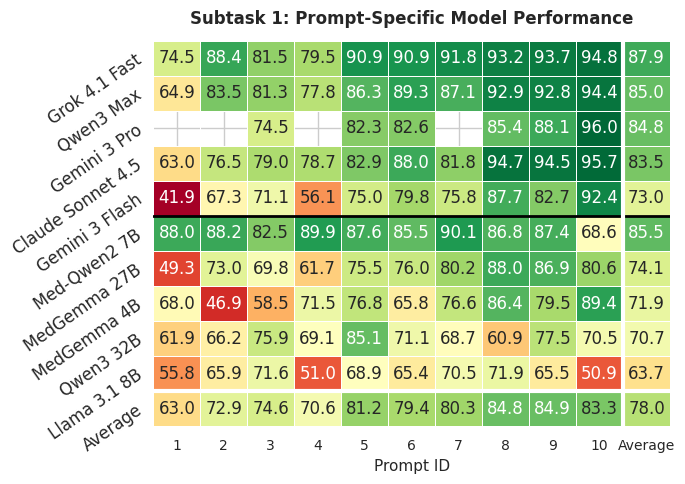

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Dev set heatmap (Closed Source vs Open Source) ───────────────────────────
DEV_RESULTS_DIR = "../results/dev"

df_dev = load_metrics(DEV_RESULTS_DIR)
df_dev['prompt_id'] = pd.to_numeric(df_dev['prompt_id'], errors='coerce')
df_dev = df_dev.dropna(subset=['prompt_id'])
df_dev['prompt_id'] = df_dev['prompt_id'].astype(int)
print(f"Loaded {len(df_dev)} dev result files.")

closed_source_models = [
    'anthropic-claude-sonnet-4-5',   
    'google-gemini-3-flash-preview', 
    'x-ai-grok-4-1-fast',            
    'google-gemini-3-pro-preview',       
    'qwen-qwen3-max',  
    'google-gemini-2-5-flash'     
]

open_source_models = [
    'meta-llama-Llama-3-1-8B-Instruct', 
    'Qwen-Qwen3-32B',                   
    'google-medgemma-27b-text-it',      
    'google-medgemma-4b-it',            
    'Echelon-AI-Med-Qwen2-7B',          
]

# ── Define Clean Aliases for the Plot ────────────────────────────────────────
model_aliases = {
    'anthropic-claude-sonnet-4-5': 'Claude Sonnet 4.5',
    'google-gemini-3-flash-preview': 'Gemini 3 Flash',
    'x-ai-grok-4-1-fast': 'Grok 4.1 Fast',
    'google-gemini-2-5-flash': 'Gemini 2.5 Flash',
    'qwen-qwen3-max': 'Qwen3 Max', # Fixed key to match your list above
    'google-gemini-3-pro-preview': 'Gemini 3 Pro',      
    
    'meta-llama-Llama-3-1-8B-Instruct': 'Llama 3.1 8B',
    'Qwen-Qwen3-32B': 'Qwen3 32B',
    'google-medgemma-27b-text-it': 'MedGemma 27B',
    'google-medgemma-4b-it': 'MedGemma 4B',
    'Echelon-AI-Med-Qwen2-7B': 'Med-Qwen2 7B',
}
# ─────────────────────────────────────────────────────────────────────────────

all_models = closed_source_models + open_source_models

# Build pivot (keep only models present in both the list and the data)
df_dev_filtered = df_dev[df_dev['model'].isin(all_models)]
pivot_dev = df_dev_filtered.pivot_table(index='model', columns='prompt_id', values='overall_score')

# Calculate Averages (Changed to 'Avg')
pivot_dev['Average'] = pivot_dev.mean(axis=1)
pivot_dev.loc['Average'] = pivot_dev.mean(axis=0)

def get_avg_dev(model):
    try:
        return pivot_dev.loc[model, 'Average']
    except KeyError:
        return -float('inf')

# Sort
closed_sorted_dev = sorted([m for m in closed_source_models if m in pivot_dev.index], key=get_avg_dev, reverse=True)
open_sorted_dev   = sorted([m for m in open_source_models   if m in pivot_dev.index], key=get_avg_dev, reverse=True)

# Reindex using 'Avg' instead of 'Average'
pivot_dev = pivot_dev.reindex(closed_sorted_dev + open_sorted_dev + ['Average'])

# Apply the clean aliases to the DataFrame index
pivot_dev.rename(index=model_aliases, inplace=True)

print(f"Closed source: {len(closed_sorted_dev)} models")
print(f"Open source:   {len(open_sorted_dev)} models")

# ── Plotting (Optimized for Legibility in Double-Column) ─────────────────────
n_closed_dev = len(closed_sorted_dev)

# Slightly taller figure to accommodate larger text without overlapping
plt.figure(figsize=(7, 5)) 

# Plot heatmap (colorbar disabled)
ax = sns.heatmap(
    pivot_dev,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    linewidths=0.5,
    annot_kws={"size": 12}, 
    cbar=False # Removes the colorbar from the right
)

# Scale down the separator lines for the smaller figure size
ax.axhline(y=n_closed_dev, color='black', linewidth=2)
ax.axvline(x=pivot_dev.shape[1] - 1, color='white', linewidth=3)
ax.axhline(y=pivot_dev.shape[0] - 1, color='white', linewidth=3)

# Adjust titles and labels with larger, paper-appropriate font sizes (Added "Overall Score")
plt.title('Subtask 1: Prompt-Specific Model Performance', fontsize=12, fontweight='bold', pad=12)
plt.ylabel('', fontsize=11)
plt.xlabel('Prompt ID', fontsize=11)

# Clean up ticks and increase their size
plt.xticks(fontsize=10, rotation=0) 
plt.yticks(fontsize=12, rotation=35, ha='right', rotation_mode='anchor')

plt.tight_layout()

# Save as PDF at 300 DPI for crisp print quality
plt.savefig('subtask1_heatmap_revised.pdf', dpi=300, bbox_inches='tight')

Closed source: 8 models
Open source:   26 models


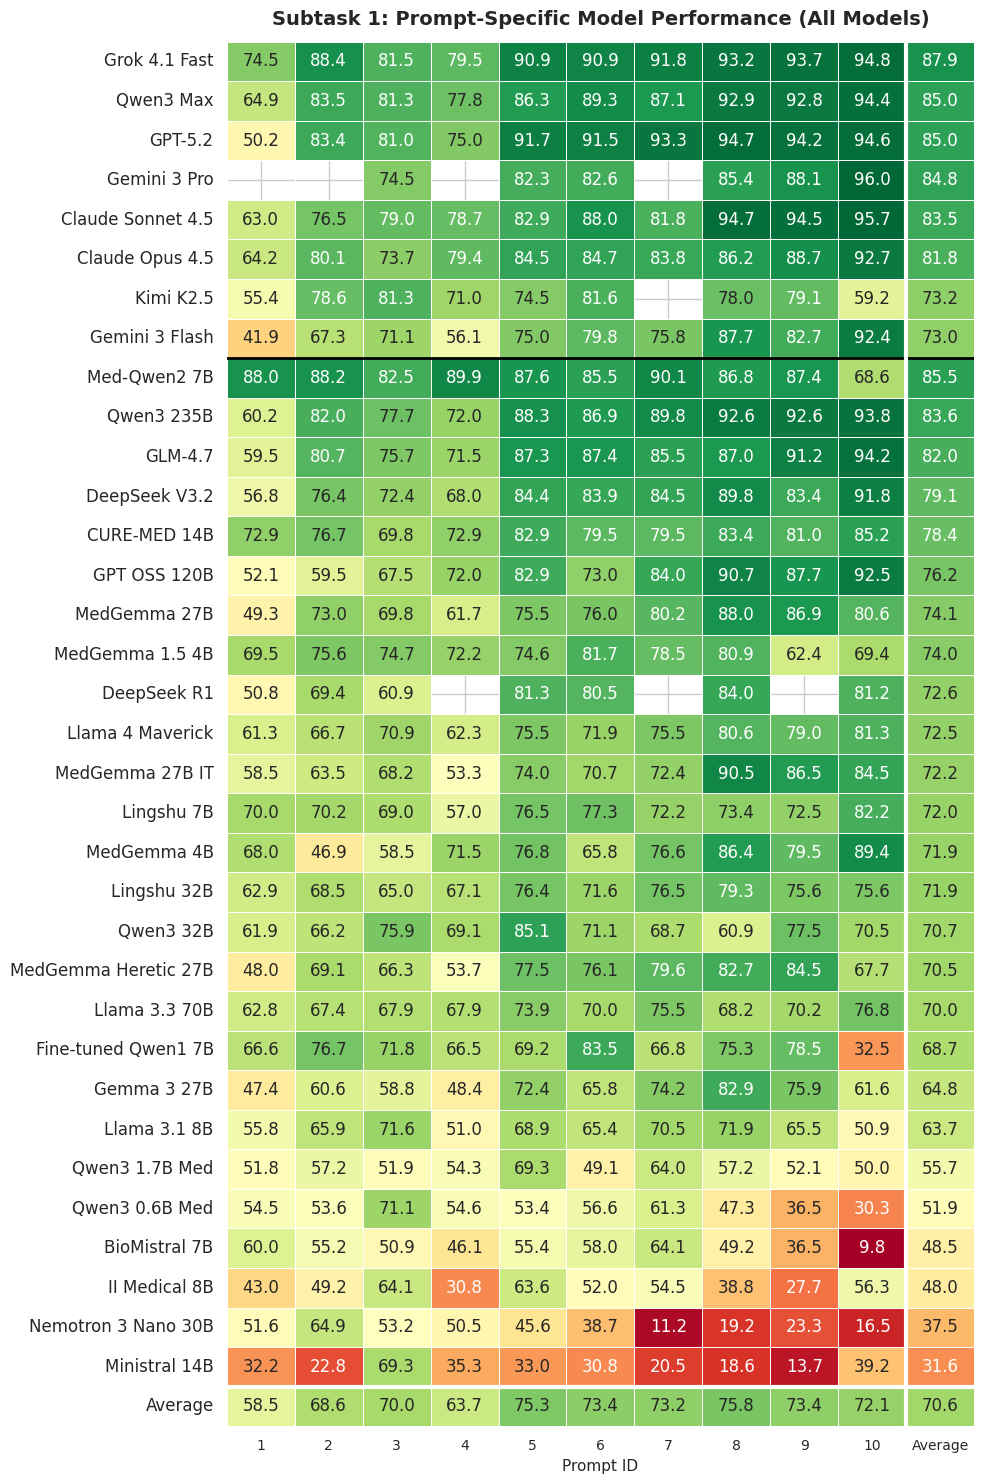

In [13]:
# ── All-models heatmap (Prompt IDs 1–10), divided by source type ─────────────
df_all = load_metrics("../results/dev")

df_all['prompt_id'] = pd.to_numeric(df_all['prompt_id'], errors='coerce')
df_all = df_all.dropna(subset=['prompt_id'])
df_all['prompt_id'] = df_all['prompt_id'].astype(int)
df_all = df_all[df_all['prompt_id'].between(1, 10)]

closed_source_models = [
    # Anthropic
    'anthropic-claude-opus-4-6',
    'anthropic-claude-opus-4-5',
    'anthropic-claude-sonnet-4-6',
    'anthropic-claude-sonnet-4-5',
    'anthropic-claude-sonnet-4',
    'anthropic-claude-haiku-4-5',
    # OpenAI
    'openai-gpt-5',
    'openai-gpt-5-1',
    'openai-gpt-5-2',
    'openai-gpt-4-1',
    'openai-gpt-4-1-mini',
    'openai-gpt-5-mini',
    'openai-gpt-5-nano',
    # Google Gemini
    'google-gemini-2-5-pro',
    'google-gemini-2-5-flash',
    'google-gemini-2-5-flash-lite',
    'google-gemini-2-0-flash-001',
    'google-gemini-3-flash-preview',
    'google-gemini-3-1-pro-preview',
    'google-gemini-3-pro-preview',
    # xAI
    'x-ai-grok-4',
    'x-ai-grok-4-fast',
    'x-ai-grok-4-1-fast',
    # Qwen (API)
    'qwen-qwen3-max',
    'qwen-qwen3-max-thinking',
    'qwen-qwen3-5-plus-02-15',
    # MiniMax
    'minimax-minimax-m2-5',
    'minimax-minimax-m2-1',
    # Moonshot
    'moonshotai-kimi-k2-thinking',
    'moonshotai-kimi-k2-5',
]

open_source_models = [
    'google-medgemma-27b-text-it',
    'google-medgemma-27b-it',
    'google-gemma-3-27b-it',
    'google-medgemma-4b-it',
    'google-medgemma-1-5-4b-it',
    'pszemraj-medgemma-27b-text-heretic_med',
    'meta-llama-Llama-3-1-8B-Instruct',
    'meta-llama-Llama-3-3-70B-Instruct',
    'meta-llama-llama-4-scout',
    'meta-llama-llama-4-maverick',
    'Qwen-Qwen3-32B',
    'Qwen-Qwen3-8B',
    'qwen-qwen3-235b-a22b-2507',
    'qwen-qwen3-5-397b-a17b',
    'qwen-qwen3-5-flash-02-23',
    'Echelon-AI-Med-Qwen2-7B',
    'Aikyam-Lab-CURE-MED-14B',
    'BioMistral-BioMistral-7B',
    'khazarai-Bio-8B-it',
    'lingshu-medical-mllm-Lingshu-7B',
    'lingshu-medical-mllm-Lingshu-32B',
    'Intelligent-Internet-II-Medical-8B-1706',
    'NotoriousH2-qwen3-1-7b-base-MED-Instruct',
    'VesileHan-fine_tuned_qwen1-7B',
    'suayptalha-Qwen3-0-6B-Medical-Expert',
    'mistralai-Ministral-3-14B-Reasoning-2512',
    'nvidia-NVIDIA-Nemotron-3-Nano-30B-A3B-FP8',
    'deepseek-deepseek-chat-v3-0324',
    'deepseek-deepseek-v3-2',
    'deepseek-deepseek-r1-0528:free',
    'xiaomi-mimo-v2-flash',
    'z-ai-glm-4-7',
    'meta-llama-llama-3-3-70b-instruct',
    'openai-gpt-oss-120b',
]

model_aliases = {
    'anthropic-claude-haiku-4-5':                    'Claude Haiku 4.5',
    'anthropic-claude-sonnet-4':                     'Claude Sonnet 4',
    'anthropic-claude-sonnet-4-5':                   'Claude Sonnet 4.5',
    'anthropic-claude-sonnet-4-6':                   'Claude Sonnet 4.6',
    'anthropic-claude-opus-4-5':                     'Claude Opus 4.5',
    'anthropic-claude-opus-4-6':                     'Claude Opus 4.6',
    'openai-gpt-4-1':                                'GPT-4.1',
    'openai-gpt-4-1-mini':                           'GPT-4.1 Mini',
    'openai-gpt-5':                                  'GPT-5',
    'openai-gpt-5-1':                                'GPT-5.1',
    'openai-gpt-5-2':                                'GPT-5.2',
    'openai-gpt-5-mini':                             'GPT-5 Mini',
    'openai-gpt-5-nano':                             'GPT-5 Nano',
    'openai-gpt-oss-120b':                           'GPT OSS 120B',
    'google-gemini-2-0-flash-001':                   'Gemini 2.0 Flash',
    'google-gemini-2-5-flash':                       'Gemini 2.5 Flash',
    'google-gemini-2-5-flash-lite':                  'Gemini 2.5 Flash Lite',
    'google-gemini-2-5-pro':                         'Gemini 2.5 Pro',
    'google-gemini-3-flash-preview':                 'Gemini 3 Flash',
    'google-gemini-3-1-pro-preview':                 'Gemini 3.1 Pro',
    'google-gemini-3-pro-preview':                   'Gemini 3 Pro',
    'x-ai-grok-4':                                   'Grok 4',
    'x-ai-grok-4-fast':                              'Grok 4 Fast',
    'x-ai-grok-4-1-fast':                            'Grok 4.1 Fast',
    'qwen-qwen3-max':                                'Qwen3 Max',
    'qwen-qwen3-max-thinking':                       'Qwen3 Max Thinking',
    'qwen-qwen3-235b-a22b-2507':                     'Qwen3 235B',
    'qwen-qwen3-5-397b-a17b':                        'Qwen3.5 397B',
    'qwen-qwen3-5-plus-02-15':                       'Qwen3.5 Plus',
    'qwen-qwen3-5-flash-02-23':                      'Qwen3.5 Flash',
    'minimax-minimax-m2-1':                          'MiniMax M2.1',
    'minimax-minimax-m2-5':                          'MiniMax M2.5',
    'moonshotai-kimi-k2-5':                          'Kimi K2.5',
    'moonshotai-kimi-k2-thinking':                   'Kimi K2 Thinking',
    'deepseek-deepseek-chat-v3-0324':                'DeepSeek V3',
    'deepseek-deepseek-v3-2':                        'DeepSeek V3.2',
    'deepseek-deepseek-r1-0528:free':                'DeepSeek R1',
    'google-medgemma-27b-text-it':                   'MedGemma 27B',
    'google-medgemma-27b-it':                        'MedGemma 27B IT',
    'google-medgemma-4b-it':                         'MedGemma 4B',
    'google-medgemma-1-5-4b-it':                     'MedGemma 1.5 4B',
    'google-gemma-3-27b-it':                         'Gemma 3 27B',
    'pszemraj-medgemma-27b-text-heretic_med':        'MedGemma Heretic 27B',
    'meta-llama-Llama-3-1-8B-Instruct':              'Llama 3.1 8B',
    'meta-llama-Llama-3-3-70B-Instruct':             'Llama 3.3 70B',
    'meta-llama-llama-3-3-70b-instruct':             'Llama 3.3 70B',
    'meta-llama-llama-4-scout':                      'Llama 4 Scout',
    'meta-llama-llama-4-maverick':                   'Llama 4 Maverick',
    'Qwen-Qwen3-32B':                                'Qwen3 32B',
    'Qwen-Qwen3-8B':                                 'Qwen3 8B',
    'Echelon-AI-Med-Qwen2-7B':                       'Med-Qwen2 7B',
    'Aikyam-Lab-CURE-MED-14B':                       'CURE-MED 14B',
    'BioMistral-BioMistral-7B':                      'BioMistral 7B',
    'khazarai-Bio-8B-it':                            'KhazarAI Bio 8B',
    'lingshu-medical-mllm-Lingshu-7B':               'Lingshu 7B',
    'lingshu-medical-mllm-Lingshu-32B':              'Lingshu 32B',
    'Intelligent-Internet-II-Medical-8B-1706':       'II Medical 8B',
    'NotoriousH2-qwen3-1-7b-base-MED-Instruct':     'Qwen3 1.7B Med',
    'VesileHan-fine_tuned_qwen1-7B':                 'Fine-tuned Qwen1 7B',
    'suayptalha-Qwen3-0-6B-Medical-Expert':          'Qwen3 0.6B Med',
    'mistralai-Ministral-3-14B-Reasoning-2512':      'Ministral 14B',
    'nvidia-NVIDIA-Nemotron-3-Nano-30B-A3B-FP8':     'Nemotron 3 Nano 30B',
    'xiaomi-mimo-v2-flash':                          'MiMo V2 Flash',
    'z-ai-glm-4-7':                                  'GLM-4.7',
    'z-ai-glm-4-7-flash':                            'GLM-4.7 Flash',
}

all_models = closed_source_models + open_source_models
df_all_filtered = df_all[df_all['model'].isin(all_models)]
pivot_all = df_all_filtered.pivot_table(index='model', columns='prompt_id', values='overall_score')

pivot_all['Average'] = pivot_all.mean(axis=1)
pivot_all.loc['Average'] = pivot_all.mean(axis=0)

def get_avg_all(m):
    try: return pivot_all.loc[m, 'Average']
    except KeyError: return -float('inf')

closed_sorted = sorted([m for m in closed_source_models if m in pivot_all.index], key=get_avg_all, reverse=True)
open_sorted   = sorted([m for m in open_source_models   if m in pivot_all.index], key=get_avg_all, reverse=True)
pivot_all = pivot_all.reindex(closed_sorted + open_sorted + ['Average'])
pivot_all.rename(index=model_aliases, inplace=True)

n_closed = len(closed_sorted)

print(f"Closed source: {len(closed_sorted)} models")
print(f"Open source:   {len(open_sorted)} models")

plt.figure(figsize=(10, 15))
ax = sns.heatmap(
    pivot_all,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    linewidths=0.5,
    annot_kws={"size": 12},
    cbar=False,
)

ax.axhline(y=n_closed, color='black', linewidth=2)
ax.axvline(x=pivot_all.shape[1] - 1, color='white', linewidth=3)
ax.axhline(y=pivot_all.shape[0] - 1, color='white', linewidth=3)

plt.title('Subtask 1: Prompt-Specific Model Performance (All Models)', fontsize=14, fontweight='bold', pad=12)
plt.ylabel('', fontsize=11)
plt.xlabel('Prompt ID', fontsize=11)
plt.xticks(fontsize=10, rotation=0)
plt.yticks(fontsize=12, rotation=0, ha='right', rotation_mode='anchor')

plt.tight_layout()
plt.savefig('subtask1_heatmap_appendix.pdf', dpi=300, bbox_inches='tight')
plt.show()

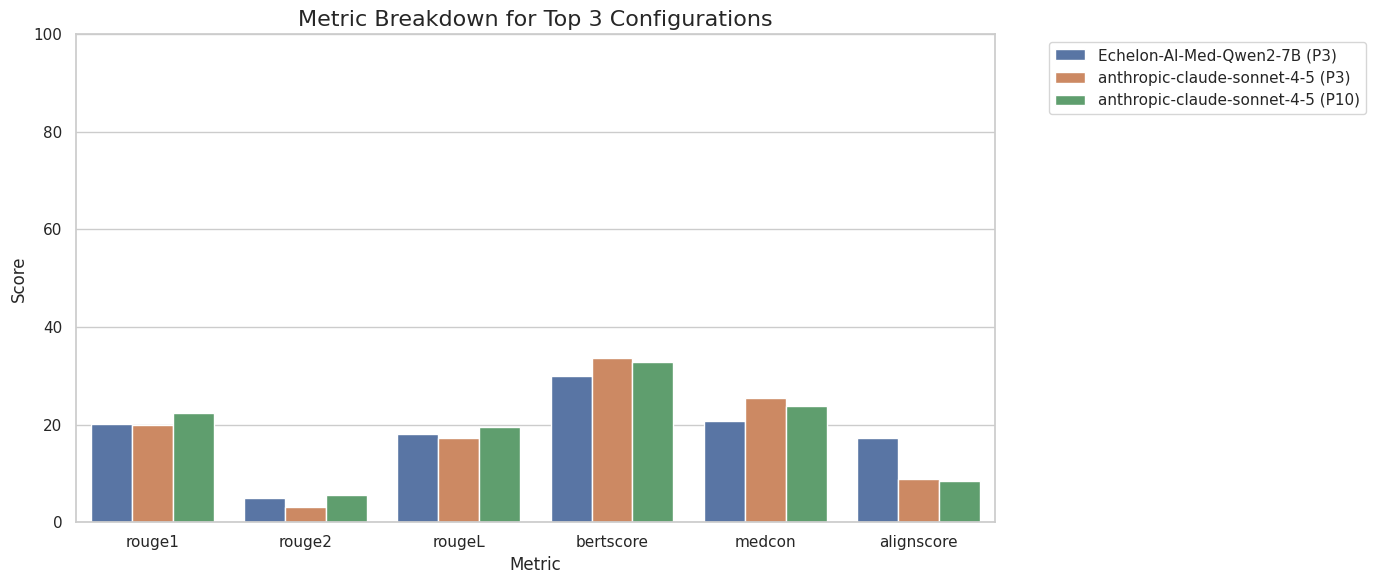

In [9]:
# Melt the dataframe to make it suitable for a grouped bar chart
top_3_configs = df.head(3)['filename'].tolist()
subset = df[df['filename'].isin(top_3_configs)]

# Select only numeric metric columns (excluding overall_score to avoid skewing scale)
metric_cols = ['rouge1', 'rouge2', 'rougeL', 'bertscore', 'medcon', 'alignscore']
melted = subset.melt(id_vars=['model', 'prompt_id'], value_vars=metric_cols, var_name='Metric', value_name='Score')

# Create label for legend
melted['Configuration'] = melted['model'] + " (P" + melted['prompt_id'].astype(str) + ")"

plt.figure(figsize=(14, 6))
sns.barplot(
    data=melted,
    x="Metric",
    y="Score",
    hue="Configuration",
    palette="deep"
)

plt.title("Metric Breakdown for Top 3 Configurations", fontsize=16)
plt.ylim(0, 100)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
import json
import os
import glob

def analyze_json_files(directory_path):
    # Check if directory exists
    if not os.path.exists(directory_path):
        print(f"Error: Directory '{directory_path}' not found.")
        return

    # Pattern to match all .json files
    search_pattern = os.path.join(directory_path, '*.json')
    files = glob.glob(search_pattern)

    print(f"Found {len(files)} JSON files in {directory_path}...\n")
    print("=" * 60)

    for filepath in files:
        filename = os.path.basename(filepath)
        
        # Counters
        total_word_count = 0
        valid_entries = 0
        error_flags = 0  # prediction == "error"
        empty_flags = 0  # prediction == ""
        
        # Store specific issue details
        issues = []

        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                # Load the whole JSON list
                data = json.load(f)
                
                if not isinstance(data, list):
                    print(f"⚠️  Skipping {filename}: Root is not a list.")
                    continue

                for index, entry in enumerate(data):
                    # Use index + 1 for user-friendly "Item ID"
                    item_num = index + 1
                    
                    # Safely get prediction, default to empty string if missing
                    prediction = entry.get("prediction", "")

                    # 1. Check for specific flags
                    if prediction == "":
                        empty_flags += 1
                        issues.append(f"Item {item_num} (Case {entry.get('case_id','?')}): Prediction is empty")
                    
                    elif prediction == "error":
                        error_flags += 1
                        issues.append(f"Item {item_num} (Case {entry.get('case_id','?')}: Prediction is 'error'")
                    
                    # 2. Count words for valid predictions
                    else:
                        # Split by whitespace to count words
                        words = len(prediction.split())
                        total_word_count += words
                        valid_entries += 1
                        if words > 15:
                            error_flags += 1
                            issues.append(f"Length")
            # --- Report for the file ---
            
            # Calculate average
            avg_words = total_word_count / valid_entries if valid_entries > 0 else 0
            
          
            # Check if we need to flag the file
            if error_flags > 0 or empty_flags > 0:
                print(f"File: {filename}")
                print(f"  Total Valid Items: {valid_entries}")
                print(f"  Total Word Count:  {total_word_count}")
                print(f"  Avg Words/Pred:    {avg_words:.2f}")

                print(f"  ⚠️  FLAGS DETECTED:")
                if empty_flags > 0: print(f"      - Empty strings: {empty_flags}")
                if error_flags > 0: print(f"      - 'Error' strings: {error_flags}")
                
                # Print first 3 specific issues as examples
                print(f"      Details (First 3):")
                for issue in issues[:3]: 
                    print(f"      * {issue}")
                print("-" * 60)

            else:
                print(f" {filename} ✅ Status: Clean")
            

        except json.JSONDecodeError:
            print(f"❌ Error decoding {filename}: Not valid JSON.")
            print("-" * 60)
        except Exception as e:
            print(f"❌ Error reading {filename}: {e}")
            print("-" * 60)

# Run the function
target_dir = '../outputs/test'
analyze_json_files(target_dir)

Found 15 JSON files in ../outputs/test...

File: Echelon-AI-Med-Qwen2-7B_prompt_8.json
  Total Valid Items: 47
  Total Word Count:  571
  Avg Words/Pred:    12.15
  ⚠️  FLAGS DETECTED:
      - 'Error' strings: 9
      Details (First 3):
      * Length
      * Length
      * Length
------------------------------------------------------------
File: google-medgemma-27b-it_prompt_10.json
  Total Valid Items: 47
  Total Word Count:  751
  Avg Words/Pred:    15.98
  ⚠️  FLAGS DETECTED:
      - 'Error' strings: 20
      Details (First 3):
      * Length
      * Length
      * Length
------------------------------------------------------------
File: openai-gpt-5-2_prompt_10.json
  Total Valid Items: 47
  Total Word Count:  683
  Avg Words/Pred:    14.53
  ⚠️  FLAGS DETECTED:
      - 'Error' strings: 1
      Details (First 3):
      * Length
------------------------------------------------------------


File: google-medgemma-27b-it_prompt_9.json
  Total Valid Items: 47
  Total Word Count:  875
  Avg Words/Pred:    18.62
  ⚠️  FLAGS DETECTED:
      - 'Error' strings: 33
      Details (First 3):
      * Length
      * Length
      * Length
------------------------------------------------------------
File: Aikyam-Lab-CURE-MED-14B_prompt_8.json
  Total Valid Items: 47
  Total Word Count:  950
  Avg Words/Pred:    20.21
  ⚠️  FLAGS DETECTED:
      - 'Error' strings: 41
      Details (First 3):
      * Length
      * Length
      * Length
------------------------------------------------------------
File: deepseek-deepseek-v3-2_prompt_10.json
  Total Valid Items: 47
  Total Word Count:  732
  Avg Words/Pred:    15.57
  ⚠️  FLAGS DETECTED:
      - 'Error' strings: 19
      Details (First 3):
      * Length
      * Length
      * Length
------------------------------------------------------------
File: anthropic-claude-sonnet-4-5_prompt_10.json
  Total Valid Items: 47
  Total Word Count:  616
